In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Downloads/house_price.csv")
df.head(3)

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305


### Basic EDA

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   location        13200 non-null  object 
 1   size            13200 non-null  object 
 2   total_sqft      13200 non-null  float64
 3   bath            13200 non-null  float64
 4   price           13200 non-null  float64
 5   bhk             13200 non-null  int64  
 6   price_per_sqft  13200 non-null  int64  
dtypes: float64(3), int64(2), object(2)
memory usage: 722.0+ KB


In [7]:
df.isnull().sum().sum()

0

In [9]:
df.describe()

,total_sqft,bath,price,bhk,price_per_sqft
count,13200.000000,13200.000000,13200.000000,13200.000000,1.320000e+04
mean,1555.302783,2.691136,112.276178,2.800833,7.920337e+03
std,1237.323445,1.338915,149.175995,1.292843,1.067272e+05
min,1.000000,1.000000,8.000000,1.000000,2.670000e+02
25%,1100.000000,2.000000,50.000000,2.000000,4.267000e+03
50%,1275.000000,2.000000,71.850000,3.000000,5.438000e+03
75%,1672.000000,3.000000,120.000000,3.000000,7.317000e+03
max,52272.000000,40.000000,3600.000000,43.000000,1.200000e+07


In [11]:
 df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
13195    False
13196    False
13197    False
13198    False
13199     True
Length: 13200, dtype: bool

In [5]:
df.duplicated().sum()

1049

In [7]:
dfc = df.drop_duplicates()
dfc.duplicated().sum()

0

## a) Mean and Standard deviation

In [9]:
""" Detect the outliers using following methods and remove it using methods like trimming / capping/ imputation using mean or median """

mean = dfc['price_per_sqft'].mean()
std = dfc['price_per_sqft'].std()

print(f'Mean : {mean:.4f}')
print(f"STD: {std:.4f}")

Mean : 8132.6418
STD: 111232.9009


In [11]:
lower_limit = mean - 3 * std
upper_limit = mean + 3 * std
print(f"The lower limit is: {lower_limit:.4f}")
print(f"The upper limit is: {upper_limit:.4f} ")

The lower limit is: -325566.0608
The upper limit is: 341831.3445 


In [13]:
# Detect and trim
df_trim_mean_std = dfc[(dfc['price_per_sqft'] >= lower_limit) & (dfc['price_per_sqft'] <= upper_limit)]
df_trim_mean_std

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250
...,...,...,...,...,...,...,...
13194,Green Glen Layout,3 BHK,1715.0,3.0,112.00,3,6530
13195,Whitefield,5 Bedroom,3453.0,4.0,231.00,5,6689
13196,other,4 BHK,3600.0,5.0,400.00,4,11111
13197,Raja Rajeshwari Nagar,2 BHK,1141.0,2.0,60.00,2,5258


## b)Percentile method

In [15]:
lower_limit = dfc['price_per_sqft'].quantile(0.05)
upper_limit = dfc['price_per_sqft'].quantile(0.95)

print(f"Lower limit: {lower_limit:.4f}")
print(f"Upper limit: {upper_limit:.4f}")

Lower limit: 3150.0000
Upper limit: 15600.0000


In [17]:
# Detect and trim
df_trim_percentile = dfc[(dfc['price_per_sqft'] >= lower_limit) & (dfc['price_per_sqft'] <= upper_limit)]
df_trim_percentile

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250
...,...,...,...,...,...,...,...
13194,Green Glen Layout,3 BHK,1715.0,3.0,112.00,3,6530
13195,Whitefield,5 Bedroom,3453.0,4.0,231.00,5,6689
13196,other,4 BHK,3600.0,5.0,400.00,4,11111
13197,Raja Rajeshwari Nagar,2 BHK,1141.0,2.0,60.00,2,5258


## c) IQR(Inter quartile range method)

In [21]:
Q1 = dfc['price_per_sqft'].quantile(0.25)
Q3 = dfc['price_per_sqft'].quantile(0.75)
IQR = Q3 - Q1

print(f"Q1: {Q1:.4f} and Q3: {Q3:.4f}")

Q1: 4312.0000 and Q3: 7461.0000


In [23]:
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
print(f"The Lower and Upper limits are {lower_limit:.4f} and {upper_limit:.4f} respectively")

The Lower and Upper limits are -411.5000 and 12184.5000 respectively


In [25]:
# Detect and trim
df_trim_iqr = dfc[(dfc['price_per_sqft'] >= lower_limit) & (dfc['price_per_sqft'] <= upper_limit)]
df_trim_iqr 

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250
...,...,...,...,...,...,...,...
13194,Green Glen Layout,3 BHK,1715.0,3.0,112.00,3,6530
13195,Whitefield,5 Bedroom,3453.0,4.0,231.00,5,6689
13196,other,4 BHK,3600.0,5.0,400.00,4,11111
13197,Raja Rajeshwari Nagar,2 BHK,1141.0,2.0,60.00,2,5258


## d) Z Score method

In [27]:
from scipy import stats
from scipy.stats import zscore

dfc['z_score'] = zscore(dfc['price_per_sqft'])
dfc.head(3)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23308\2880201412.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfc['z_score'] = zscore(dfc['price_per_sqft'])


,location,size,total_sqft,bath,price,bhk,price_per_sqft,z_score
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699,-0.039861
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615,-0.031625
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305,-0.034412


In [29]:
df_trim_zscore = dfc[(dfc['z_score'] >= -3) & (dfc['z_score'] <= 3)]
df_trim_zscore

,location,size,total_sqft,bath,price,bhk,price_per_sqft,z_score
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699,-0.039861
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615,-0.031625
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305,-0.034412
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245,-0.016971
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250,-0.034907
...,...,...,...,...,...,...,...,...
13194,Green Glen Layout,3 BHK,1715.0,3.0,112.00,3,6530,-0.014409
13195,Whitefield,5 Bedroom,3453.0,4.0,231.00,5,6689,-0.012979
13196,other,4 BHK,3600.0,5.0,400.00,4,11111,0.026777
13197,Raja Rajeshwari Nagar,2 BHK,1141.0,2.0,60.00,2,5258,-0.025845


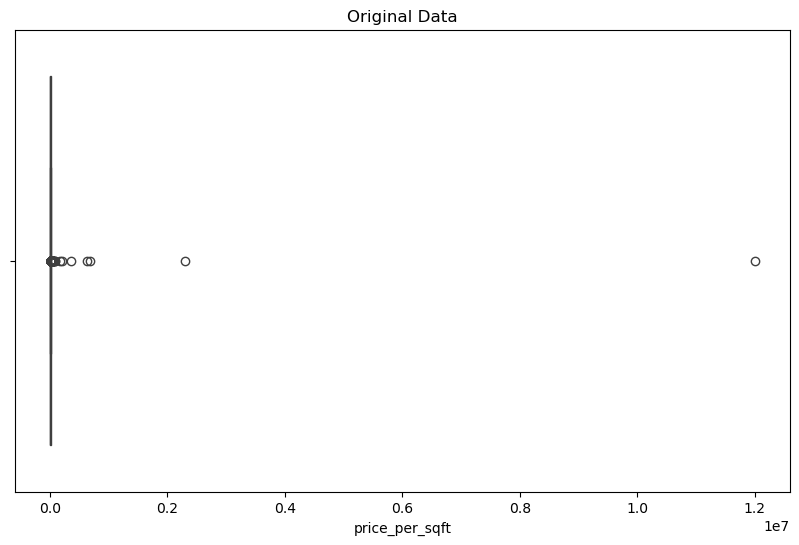

In [31]:
# Original boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=dfc, x='price_per_sqft')
plt.title("Original Data")
plt.show()

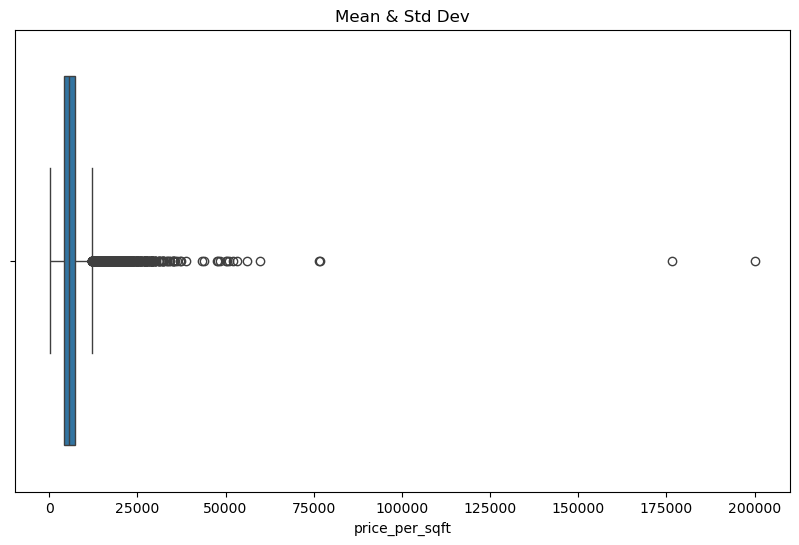

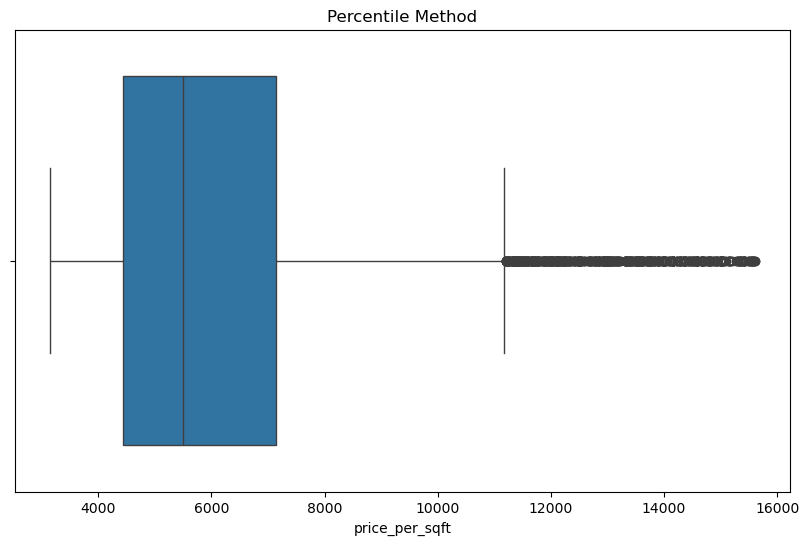

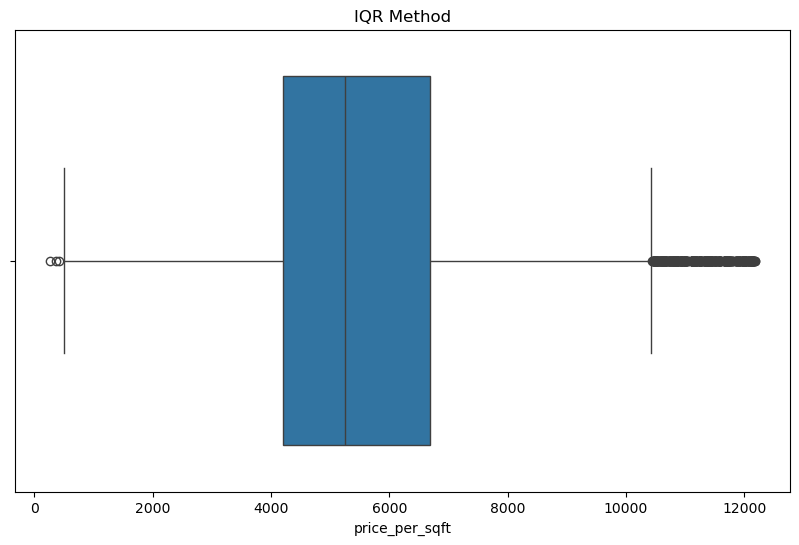

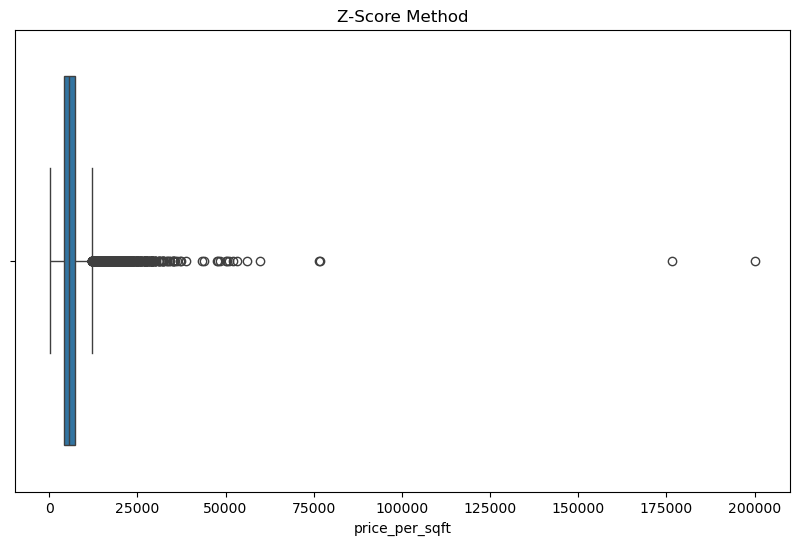

In [33]:
# After applying each method
methods = [df_trim_mean_std, df_trim_percentile, df_trim_iqr, df_trim_zscore]
titles = ['Mean & Std Dev', 'Percentile Method', 'IQR Method', 'Z-Score Method']

for method, title in zip(methods, titles):
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=method, x='price_per_sqft')
    plt.title(title)
    plt.show()

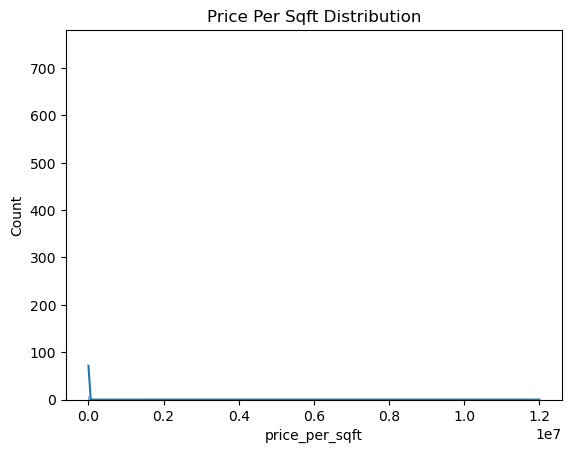

Skewness: 103.88920549434178
Kurtosis: 11131.230839805388


In [35]:
from scipy.stats import skew, kurtosis

# Histogram
sns.histplot(data= dfc['price_per_sqft'], kde=True)
plt.title("Price Per Sqft Distribution")
plt.show()

# Skewness and Kurtosis
print("Skewness:", skew(dfc['price_per_sqft']))
print("Kurtosis:", kurtosis(dfc['price_per_sqft']))


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23308\3115708409.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfc['price_per_sqft_log'] = np.log1p(dfc['price_per_sqft'])


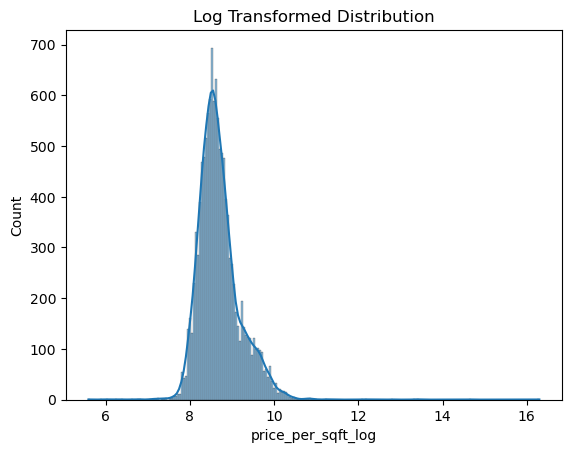

Skewness (Log): 1.400870354404583
Kurtosis (Log): 9.404434549652514


In [37]:
# Log Transformation
dfc['price_per_sqft_log'] = np.log1p(dfc['price_per_sqft'])

# Re-check histogram
sns.histplot(data = dfc['price_per_sqft_log'], kde=True)
plt.title("Log Transformed Distribution")
plt.show()

# Re-check skewness and kurtosis
print("Skewness (Log):", skew(dfc['price_per_sqft_log']))
print("Kurtosis (Log):", kurtosis(dfc['price_per_sqft_log']))


In [39]:
dfcc = dfc.drop(['location','size','z_score'],axis=1)

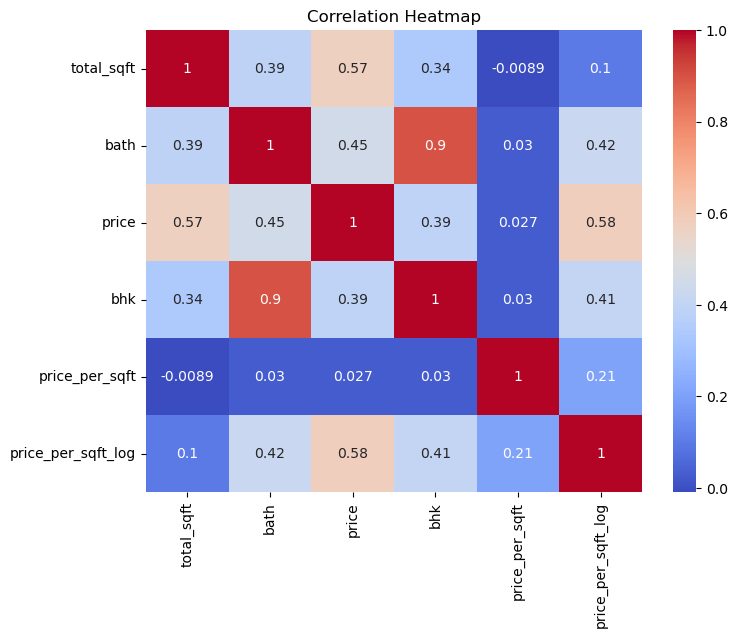

In [41]:
# Compute correlation

correlation_matrix = dfcc.corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

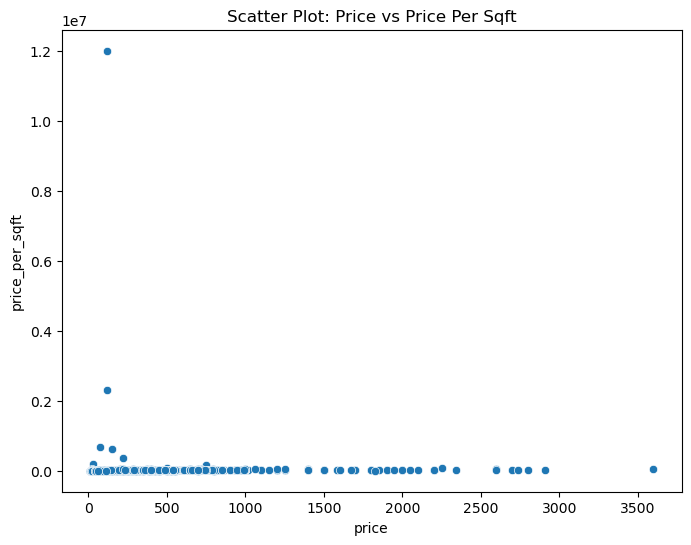

In [43]:
# Example: Scatter plot between 'price' and 'price_per_sqft'
plt.figure(figsize=(8, 6))
sns.scatterplot(data=dfcc, x='price', y='price_per_sqft')
plt.title("Scatter Plot: Price vs Price Per Sqft")
plt.show()